<a href="https://colab.research.google.com/github/shraya06/DATA_ANALYTICS/blob/main/Netflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/netflix_titles.csv')

print("First 5 rows of the dataset:")
display(df.head())

print("\nDataFrame Info:")
df.info()

First 5 rows of the dataset:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


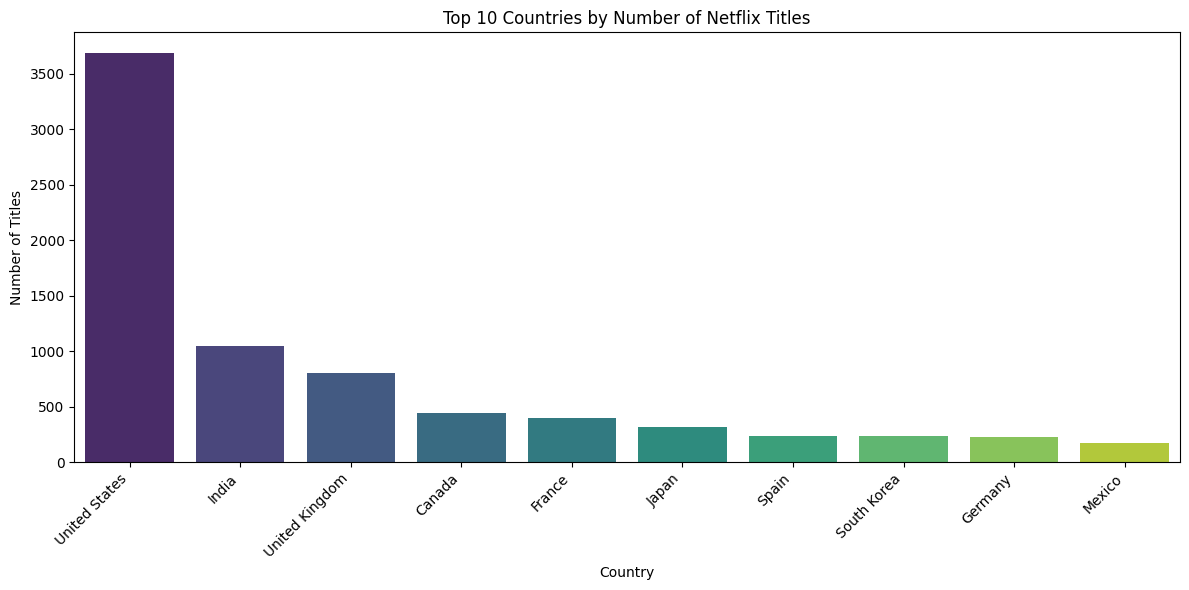

In [4]:
df_countries = df['country'].dropna().apply(lambda x: [c.strip() for c in x.split(',')]).explode()

top_10_countries = df_countries.value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_countries.index, y=top_10_countries.values, hue=top_10_countries.index, palette='viridis', legend=False)
plt.title('Top 10 Countries by Number of Netflix Titles')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

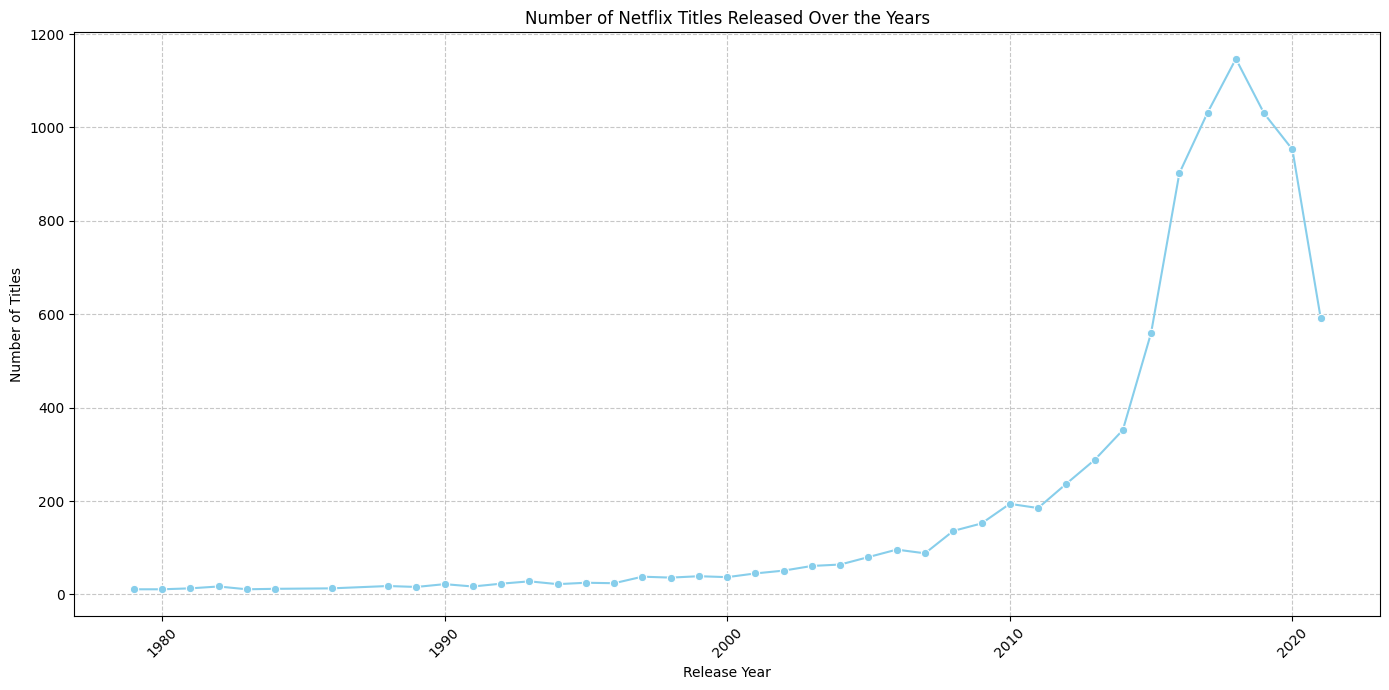

In [3]:
# Count the number of titles per release year
releases_by_year = df['release_year'].value_counts().sort_index()

# Filter for years with a reasonable number of releases to avoid sparse data points at the ends
# For example, only years with more than 10 releases
releases_by_year = releases_by_year[releases_by_year > 10]

plt.figure(figsize=(14, 7))
sns.lineplot(x=releases_by_year.index, y=releases_by_year.values, marker='o', color='skyblue')
plt.title('Number of Netflix Titles Released Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Plot 3: Distribution of Content Types (Movies vs. TV Shows)

This column chart will show the count of 'Movie' and 'TV Show' titles available on Netflix, providing a clear overview of the platform's content mix.

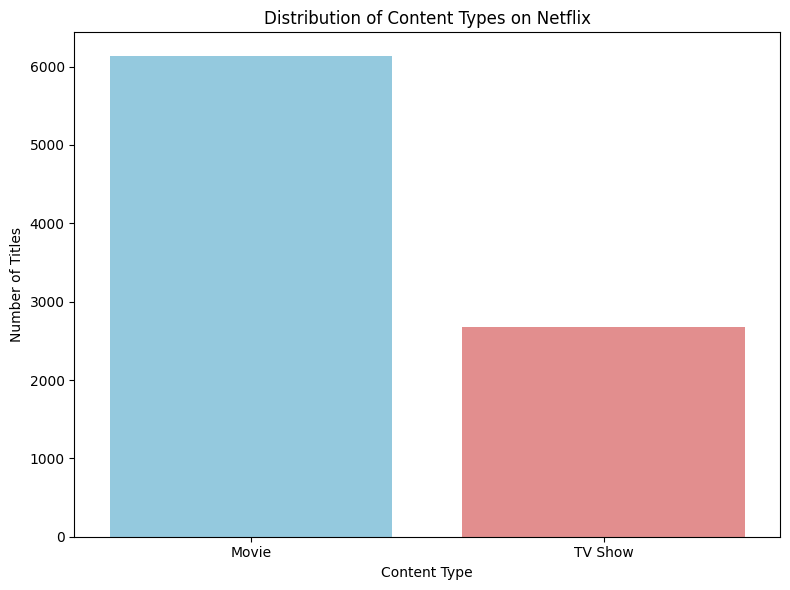

In [5]:
# Count the occurrences of each content type
content_type_distribution = df['type'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=content_type_distribution.index, y=content_type_distribution.values, hue=content_type_distribution.index, palette=['skyblue', 'lightcoral'], legend=False)
plt.title('Distribution of Content Types on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()